# Maternal Sarisfaction ML Project

### 1.The first step we have to do is importing all the neccessary library

In [5]:
import pandas as pd

In [6]:
import pandas as pd
import numpy as np
import pyreadstat
import joblib
import json
import plotly
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, brier_score_loss,
                              confusion_matrix, classification_report, roc_curve)
from sklearn.inspection import permutation_importance


### 2.Uploading the spss dataset

In [7]:
data, meta=pyreadstat.read_sav('Delivery_care_satisfaction.sav')

In [8]:
print(data.columns.tolist())

['q101age', 'q102mstatu', 'q103religi', 'q104ethini', 'q105educat', 'q106occupa', 'q107mincom', 'q108reside', 'q1091distk', 'q1092disth', 'q110reason', 'q111timeta', 'q112waitpl', 'q113privac', 'q201parity', 'q202cpplan', 'q203ancatt', 'q204hivres', 'q205ga', 'q206delimo', 'q207nstatu', 'q208pdhsta', 'q209nsex', 'q2010bw', 'q301greeti', 'q302respec', 'q303delive', 'q411owners', 'ageafterrecod', 'monthlyincomerecode', 'gestationaagerecode', 'birthweightofbaby', 'satisfaction', 'modeofdeliveryrecode', 'waitingtimerecode', 'privacyrecode', 'encourageandsupportatdeliveryrecode', 'politenessrecode', 'availabilityofmedicalequipmentsrecode', 'counselingrecode', 'overallcleanessrecode', 'accessandcleanessoftoiletrecode', 'waitingareacleanessandconfort', 'availabilityofbedintheward', 'distancerecode1', 'wolkingdistancerecodeinhrs']


In [9]:
print(meta.variable_value_labels)

{'q102mstatu': {1.0: 'single', 2.0: 'married', 3.0: 'cohabited', 4.0: 'widowed', 5.0: 'divorced'}, 'q103religi': {1.0: 'orthodox', 2.0: 'muslim', 3.0: 'protestant', 4.0: 'orhers'}, 'q104ethini': {1.0: 'amhara', 2.0: 'oromo', 3.0: 'tigrie', 4.0: 'agew', 88.0: 'others'}, 'q105educat': {1.0: 'able to read and write', 2.0: 'unable to read and write', 3.0: 'grade 1 to 4', 4.0: 'grade 5 to 8', 5.0: 'grade 9 to 10', 6.0: 'grade 11 to 12', 7.0: 'diploma and above'}, 'q106occupa': {1.0: 'governmental', 2.0: 'merchants', 3.0: 'huose wife', 4.0: 'farmer', 5.0: 'students', 88.0: 'others'}, 'q108reside': {1.0: 'urban', 2.0: 'rural'}, 'q110reason': {1.0: 'planed', 2.0: 'refered'}, 'q111timeta': {1.0: '<1hr', 2.0: '>1hr'}, 'q112waitpl': {1.0: 'yes', 2.0: 'no'}, 'q113privac': {1.0: 'yes', 2.0: 'no'}, 'q201parity': {1.0: '1 child', 2.0: '2-5 childrens', 3.0: '>5 childrens'}, 'q202cpplan': {1.0: 'yes', 2.0: 'no'}, 'q203ancatt': {1.0: 'yes', 2.0: 'no'}, 'q204hivres': {1.0: 'HIV positive', 2.0: 'HIV negat

In [10]:
print(meta.variable_value_labels.get('satisfaction'))

{1.0: 'not satisfied', 2.0: 'satisfied'}


### 3.Data Understanding

In [11]:
data.head()

,q101age,q102mstatu,q103religi,q104ethini,q105educat,q106occupa,q107mincom,q108reside,q1091distk,q1092disth,...,encourageandsupportatdeliveryrecode,politenessrecode,availabilityofmedicalequipmentsrecode,counselingrecode,overallcleanessrecode,accessandcleanessoftoiletrecode,waitingareacleanessandconfort,availabilityofbedintheward,distancerecode1,wolkingdistancerecodeinhrs
0,22.0,2.0,1.0,1.0,4.0,88.0,800.0,2.0,0.0,200.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0
1,35.0,2.0,1.0,3.0,4.0,2.0,7000.0,1.0,0.0,50.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0
2,20.0,2.0,1.0,1.0,5.0,2.0,1500.0,1.0,5.0,NaN,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,NaN
3,26.0,2.0,1.0,1.0,3.0,3.0,900.0,1.0,0.0,11.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0
4,22.0,2.0,2.0,1.0,6.0,5.0,1536.0,2.0,5.0,NaN,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,NaN


In [12]:
data.tail()

,q101age,q102mstatu,q103religi,q104ethini,q105educat,q106occupa,q107mincom,q108reside,q1091distk,q1092disth,...,encourageandsupportatdeliveryrecode,politenessrecode,availabilityofmedicalequipmentsrecode,counselingrecode,overallcleanessrecode,accessandcleanessoftoiletrecode,waitingareacleanessandconfort,availabilityofbedintheward,distancerecode1,wolkingdistancerecodeinhrs
889,29.0,3.0,2.0,2.0,6.0,88.0,2200.0,1.0,30.0,NaN,...,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,2.0,NaN
890,31.0,2.0,1.0,1.0,7.0,1.0,4530.0,1.0,20.0,NaN,...,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,2.0,NaN
891,21.0,2.0,1.0,1.0,6.0,3.0,2500.0,1.0,0.0,1.0,...,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
892,18.0,1.0,2.0,1.0,7.0,1.0,3230.0,1.0,15.0,NaN,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,NaN
893,22.0,3.0,2.0,4.0,6.0,2.0,1500.0,1.0,10.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN


In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 894 entries, 0 to 893
Data columns (total 46 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   q101age                                894 non-null    float64
 1   q102mstatu                             894 non-null    float64
 2   q103religi                             894 non-null    float64
 3   q104ethini                             894 non-null    float64
 4   q105educat                             894 non-null    float64
 5   q106occupa                             894 non-null    float64
 6   q107mincom                             894 non-null    float64
 7   q108reside                             894 non-null    float64
 8   q1091distk                             894 non-null    float64
 9   q1092disth                             320 non-null    float64
 10  q110reason                             894 non-null    float64
 11  q111timeta       

In [14]:
data['q1092disth'].isnull().sum()

np.int64(574)

In [15]:
data.columns

Index(['q101age', 'q102mstatu', 'q103religi', 'q104ethini', 'q105educat',
       'q106occupa', 'q107mincom', 'q108reside', 'q1091distk', 'q1092disth',
       'q110reason', 'q111timeta', 'q112waitpl', 'q113privac', 'q201parity',
       'q202cpplan', 'q203ancatt', 'q204hivres', 'q205ga', 'q206delimo',
       'q207nstatu', 'q208pdhsta', 'q209nsex', 'q2010bw', 'q301greeti',
       'q302respec', 'q303delive', 'q411owners', 'ageafterrecod',
       'monthlyincomerecode', 'gestationaagerecode', 'birthweightofbaby',
       'satisfaction', 'modeofdeliveryrecode', 'waitingtimerecode',
       'privacyrecode', 'encourageandsupportatdeliveryrecode',
       'politenessrecode', 'availabilityofmedicalequipmentsrecode',
       'counselingrecode', 'overallcleanessrecode',
       'accessandcleanessoftoiletrecode', 'waitingareacleanessandconfort',
       'availabilityofbedintheward', 'distancerecode1',
       'wolkingdistancerecodeinhrs'],
      dtype='str')

In [16]:
data['satisfaction'].value_counts()

satisfaction
2.0    549
1.0    345
Name: count, dtype: int64

In [17]:
data['wolkingdistancerecodeinhrs'].value_counts()

wolkingdistancerecodeinhrs
2.0    275
Name: count, dtype: int64

In [18]:
print(f"Number of observations (mothers): {data.shape[0]}")
print(f"Number of variables: {data.shape[1]}")
print()

Number of observations (mothers): 894
Number of variables: 46



In [19]:
print(data.shape)

print(data.columns.tolist())

print(data.dtypes)

print(data.isnull().sum())

print("Duplicates:", data.duplicated().sum())

print(data["satisfaction"].value_counts(dropna=False))

(894, 46)
['q101age', 'q102mstatu', 'q103religi', 'q104ethini', 'q105educat', 'q106occupa', 'q107mincom', 'q108reside', 'q1091distk', 'q1092disth', 'q110reason', 'q111timeta', 'q112waitpl', 'q113privac', 'q201parity', 'q202cpplan', 'q203ancatt', 'q204hivres', 'q205ga', 'q206delimo', 'q207nstatu', 'q208pdhsta', 'q209nsex', 'q2010bw', 'q301greeti', 'q302respec', 'q303delive', 'q411owners', 'ageafterrecod', 'monthlyincomerecode', 'gestationaagerecode', 'birthweightofbaby', 'satisfaction', 'modeofdeliveryrecode', 'waitingtimerecode', 'privacyrecode', 'encourageandsupportatdeliveryrecode', 'politenessrecode', 'availabilityofmedicalequipmentsrecode', 'counselingrecode', 'overallcleanessrecode', 'accessandcleanessoftoiletrecode', 'waitingareacleanessandconfort', 'availabilityofbedintheward', 'distancerecode1', 'wolkingdistancerecodeinhrs']
q101age                                  float64
q102mstatu                               float64
q103religi                               float64
q104ethi

In [20]:
missing = data.isnull().sum()

print(missing[missing > 0])
print("Total missing values:", data.isnull().sum().sum())

q1092disth                    574
wolkingdistancerecodeinhrs    619
dtype: int64
Total missing values: 1193


In [21]:
variable_info = pd.DataFrame({
    "Variable": data.columns,
    "Data_Type": data.dtypes.astype(str),
    "Missing": data.isnull().sum(),
    "Unique_Values": data.nunique()
})

print(variable_info.to_string(index=False))

                             Variable Data_Type  Missing  Unique_Values
                              q101age   float64        0             24
                           q102mstatu   float64        0              5
                           q103religi   float64        0              4
                           q104ethini   float64        0              4
                           q105educat   float64        0              7
                           q106occupa   float64        0              6
                           q107mincom   float64        0            334
                           q108reside   float64        0              2
                           q1091distk   float64        0             45
                           q1092disth   float64      574             28
                           q110reason   float64        0              2
                           q111timeta   float64        0              2
                           q112waitpl   float64        0        

In [22]:
categorical_vars = [
    "q102mstatu",
    "q103religi",
    "q104ethini",
    "q105educat",
    # add the other categorical variables here
    "satisfaction"
]

In [23]:
# Show SPSS value labels for all variables

for col in data.columns:
    labels = meta.variable_value_labels.get(col)

    if labels:
        print("\n==============================")
        print(col)
        print("==============================")

        for code, label in labels.items():
            print(f"{code} = {label}")


q102mstatu
1.0 = single
2.0 = married
3.0 = cohabited
4.0 = widowed
5.0 = divorced

q103religi
1.0 = orthodox
2.0 = muslim
3.0 = protestant
4.0 = orhers

q104ethini
1.0 = amhara
2.0 = oromo
3.0 = tigrie
4.0 = agew
88.0 = others

q105educat
1.0 = able to read and write
2.0 = unable to read and write
3.0 = grade 1 to 4
4.0 = grade 5 to 8
5.0 = grade 9 to 10
6.0 = grade 11 to 12
7.0 = diploma and above

q106occupa
1.0 = governmental
2.0 = merchants
3.0 = huose wife
4.0 = farmer
5.0 = students
88.0 = others

q108reside
1.0 = urban
2.0 = rural

q110reason
1.0 = planed
2.0 = refered

q111timeta
1.0 = <1hr
2.0 = >1hr

q112waitpl
1.0 = yes
2.0 = no

q113privac
1.0 = yes
2.0 = no

q201parity
1.0 = 1 child
2.0 = 2-5 childrens
3.0 = >5 childrens

q202cpplan
1.0 = yes
2.0 = no

q203ancatt
1.0 = yes
2.0 = no

q204hivres
1.0 = HIV positive
2.0 = HIV negative
3.0 = not tested

q206delimo
1.0 = spontaneous vaginal delivery
2.0 = assisted delivery
3.0 = CS

q207nstatu
1.0 = alive
2.0 = still birth

q2

In [24]:
for i, col in enumerate(data.columns, start=1):
    label = meta.column_names_to_labels.get(col, "No label")
    print(f"{i}. {col} : {label}")

1. q101age : None
2. q102mstatu : marital status
3. q103religi : religion
4. q104ethini : ethinicity
5. q105educat : educational status
6. q106occupa : occupation
7. q107mincom : monthly income
8. q108reside : residence
9. q1091distk : distance in kelometers
10. q1092disth : None
11. q110reason : reasons to visit hospital
12. q111timeta : time taken to get professionals
13. q112waitpl : presence of waiting area
14. q113privac : gender privacy during physical examination
15. q201parity : no of children
16. q202cpplan : is the current pregnancy is planned?
17. q203ancatt : ANC follow up
18. q204hivres : what was your HIV status
19. q205ga : what was the gestational age?
20. q206delimo : mode of delivery
21. q207nstatu : fetal outcome
22. q208pdhsta : is there any problem on health condition of the mother after delivery?
23. q209nsex : sex of the baby
24. q2010bw : weight of the new born in grams
25. q301greeti : was the professional give greeting for you?
26. q302respec : respectfull pra

In [25]:
for i, col in enumerate(data.columns, start=1):
    if 26 <= i <= 42:
        label = meta.column_names_to_labels.get(col, "No label")
        print(f"{i}. {col} : {label}")

26. q302respec : respectfull practice of the professional during delivery process
27. q303delive : sex of health care provider
28. q411owners : ownership of the facility/hospital
29. ageafterrecod : age after recod
30. monthlyincomerecode : average monthly income after recode
31. gestationaagerecode : gestational age after recode
32. birthweightofbaby : birth weight of the baby
33. satisfaction : satisfaction
34. modeofdeliveryrecode : mode of delivery after recode
35. waitingtimerecode : waiting time  after recode
36. privacyrecode : privacy after recode
37. encourageandsupportatdeliveryrecode : encourage and support after recode
38. politenessrecode : politeness after recode
39. availabilityofmedicalequipmentsrecode : availability of medical equipments after recode
40. counselingrecode : counseling after recode
41. overallcleanessrecode : over all cleaness after recode
42. accessandcleanessoftoiletrecode : access and cleaness of toilet after recode


In [26]:
summary = pd.DataFrame({
    "Variable": data.columns,
    "Missing": data.isna().sum().values,
    "Unique_values": data.nunique(dropna=True).values
})

print(summary.to_string(index=False))

                             Variable  Missing  Unique_values
                              q101age        0             24
                           q102mstatu        0              5
                           q103religi        0              4
                           q104ethini        0              4
                           q105educat        0              7
                           q106occupa        0              6
                           q107mincom        0            334
                           q108reside        0              2
                           q1091distk        0             45
                           q1092disth      574             28
                           q110reason        0              2
                           q111timeta        0              2
                           q112waitpl        0              2
                           q113privac        0              2
                           q201parity        0              3
        

In [27]:
# Show values and SPSS labels for variables with 10 or fewer unique values

for col in data.columns:
    if data[col].nunique(dropna=True) <= 10:

        print("\n==============================")
        print(col)
        print("==============================")

        print("Values:")
        print(data[col].value_counts(dropna=False))

        print("SPSS labels:")
        print(meta.variable_value_labels.get(col, "No value labels"))


q102mstatu
Values:
q102mstatu
2.0    712
1.0     98
3.0     67
4.0     10
5.0      7
Name: count, dtype: int64
SPSS labels:
{1.0: 'single', 2.0: 'married', 3.0: 'cohabited', 4.0: 'widowed', 5.0: 'divorced'}

q103religi
Values:
q103religi
1.0     608
2.0     193
3.0      88
88.0      5
Name: count, dtype: int64
SPSS labels:
{1.0: 'orthodox', 2.0: 'muslim', 3.0: 'protestant', 4.0: 'orhers'}

q104ethini
Values:
q104ethini
1.0    715
2.0     95
4.0     47
3.0     37
Name: count, dtype: int64
SPSS labels:
{1.0: 'amhara', 2.0: 'oromo', 3.0: 'tigrie', 4.0: 'agew', 88.0: 'others'}

q105educat
Values:
q105educat
7.0    321
6.0    154
5.0    146
2.0    117
4.0     80
1.0     49
3.0     27
Name: count, dtype: int64
SPSS labels:
{1.0: 'able to read and write', 2.0: 'unable to read and write', 3.0: 'grade 1 to 4', 4.0: 'grade 5 to 8', 5.0: 'grade 9 to 10', 6.0: 'grade 11 to 12', 7.0: 'diploma and above'}

q106occupa
Values:
q106occupa
3.0     288
1.0     263
2.0     128
88.0    102
4.0      74
5.0

In [28]:
for i, col in enumerate(data.columns, start=1):
    if 16 <= i <= 30:
        print("\n==============================")
        print(f"{i}. {col}")
        print("==============================")
        print("Values:")
        print(data[col].value_counts(dropna=False))
        print("SPSS labels:")
        print(meta.variable_value_labels.get(col, "No value labels"))


16. q202cpplan
Values:
q202cpplan
1.0    825
2.0     69
Name: count, dtype: int64
SPSS labels:
{1.0: 'yes', 2.0: 'no'}

17. q203ancatt
Values:
q203ancatt
1.0    831
2.0     63
Name: count, dtype: int64
SPSS labels:
{1.0: 'yes', 2.0: 'no'}

18. q204hivres
Values:
q204hivres
2.0    739
3.0    111
1.0     44
Name: count, dtype: int64
SPSS labels:
{1.0: 'HIV positive', 2.0: 'HIV negative', 3.0: 'not tested'}

19. q205ga
Values:
q205ga
39.0    288
40.0    234
38.0     93
42.0     91
37.0     71
41.0     68
36.0     33
43.0     14
35.0      1
32.0      1
Name: count, dtype: int64
SPSS labels:
No value labels

20. q206delimo
Values:
q206delimo
3.0    446
1.0    310
2.0    138
Name: count, dtype: int64
SPSS labels:
{1.0: 'spontaneous vaginal delivery', 2.0: 'assisted delivery', 3.0: 'CS'}

21. q207nstatu
Values:
q207nstatu
1.0    877
2.0     17
Name: count, dtype: int64
SPSS labels:
{1.0: 'alive', 2.0: 'still birth'}

22. q208pdhsta
Values:
q208pdhsta
1.0    657
2.0    237
Name: count, dtype:

In [29]:
for i, col in enumerate(data.columns, start=1):
    if 31 <= i <= 46:
        print("\n==============================")
        print(f"{i}. {col}")
        print("==============================")
        print("Values:")
        print(data[col].value_counts(dropna=False))
        print("SPSS labels:")
        print(meta.variable_value_labels.get(col, "No value labels"))


31. gestationaagerecode
Values:
gestationaagerecode
2.0    774
1.0    106
3.0     14
Name: count, dtype: int64
SPSS labels:
{1.0: '28-37 weeks', 2.0: '38-42 weeks', 3.0: '>42 weeks'}

32. birthweightofbaby
Values:
birthweightofbaby
2.0    738
1.0    142
3.0     14
Name: count, dtype: int64
SPSS labels:
{1.0: '<2500 grams', 2.0: '2500-4000 grams', 3.0: '>4000 grams'}

33. satisfaction
Values:
satisfaction
2.0    549
1.0    345
Name: count, dtype: int64
SPSS labels:
{1.0: 'not satisfied', 2.0: 'satisfied'}

34. modeofdeliveryrecode
Values:
modeofdeliveryrecode
1.0    448
2.0    446
Name: count, dtype: int64
SPSS labels:
{1.0: 'vaginal delivery', 2.0: 'CS'}

35. waitingtimerecode
Values:
waitingtimerecode
2.0    692
1.0    202
Name: count, dtype: int64
SPSS labels:
{1.0: 'not satisfied', 2.0: 'satisfied'}

36. privacyrecode
Values:
privacyrecode
2.0    707
1.0    187
Name: count, dtype: int64
SPSS labels:
{1.0: 'not satisfied', 2.0: 'satisfied'}

37. encourageandsupportatdeliveryrecode
V

In [30]:
print("q1092disth values:")
print(data["q1092disth"].value_counts(dropna=False).sort_index())

q1092disth values:
q1092disth
1.0       31
2.0       14
3.0       27
4.0       21
5.0       13
6.0        2
7.0        2
8.0        4
10.0      44
11.0       1
12.0       2
15.0      18
17.0       1
18.0       2
20.0      39
25.0       2
28.0       1
29.0       1
30.0      73
31.0       1
35.0       3
37.0       1
40.0      11
45.0       2
50.0       1
60.0       1
100.0      1
200.0      1
NaN      574
Name: count, dtype: int64


In [31]:
print("\nq205ga values:")
print(data["q205ga"].value_counts(dropna=False).sort_index())


q205ga values:
q205ga
32.0      1
35.0      1
36.0     33
37.0     71
38.0     93
39.0    288
40.0    234
41.0     68
42.0     91
43.0     14
Name: count, dtype: int64


In [32]:
print("q1092disth:")
print(data["q1092disth"].describe())

print("\nq205ga:")
print(data["q205ga"].describe())

q1092disth:
count    320.000000
mean      16.671875
std       16.815293
min        1.000000
25%        4.000000
50%       12.000000
75%       30.000000
max      200.000000
Name: q1092disth, dtype: float64

q205ga:
count    894.000000
mean      39.395973
std        1.550864
min       32.000000
25%       39.000000
50%       39.000000
75%       40.000000
max       43.000000
Name: q205ga, dtype: float64


## 4.Descriptive Statistics

In [33]:
numerical_variables = [
    "q101age",
    "q107mincom",
    "q1091distk",
    "q1092disth",
    "q205ga",
    "q2010bw"
]

numerical_summary = data[numerical_variables].describe(
    percentiles=[0.25, 0.50, 0.75]
).T

numerical_summary["variance"] = data[numerical_variables].var()

numerical_summary = numerical_summary[
    ["count", "mean", "std", "variance", "min", "25%", "50%", "75%", "max"]
]

print(numerical_summary)

            count         mean          std      variance     min      25%  \
q101age     894.0    26.602908     4.881351  2.382758e+01    17.0    23.00   
q107mincom  894.0  4096.879195  4470.313904  1.998371e+07   200.0  1537.75   
q1091distk  894.0    19.286353    44.228470  1.956158e+03     0.0     0.00   
q1092disth  320.0    16.671875    16.815293  2.827541e+02     1.0     4.00   
q205ga      894.0    39.395973     1.550864  2.405180e+00    32.0    39.00   
q2010bw     894.0  2941.728188   540.414864  2.920482e+05  1111.0  2600.00   

               50%     75%      max  
q101age       27.0    30.0     42.0  
q107mincom  3000.0  5300.0  50000.0  
q1091distk     5.0    15.0    500.0  
q1092disth    12.0    30.0    200.0  
q205ga        39.0    40.0     43.0  
q2010bw     2900.0  3200.0   5001.0  


In [34]:
percentiles = data[numerical_variables].quantile(
    [0.10, 0.25, 0.50, 0.75, 0.90]
).T

percentiles.columns = [
    "P10", "P25", "P50", "P75", "P90"
]

print(percentiles)

               P10      P25     P50     P75     P90
q101age       20.0    23.00    27.0    30.0    33.0
q107mincom   853.0  1537.75  3000.0  5300.0  7650.0
q1091distk     0.0     0.00     5.0    15.0    50.0
q1092disth     2.0     4.00    12.0    30.0    30.0
q205ga        37.0    39.00    39.0    40.0    42.0
q2010bw     2200.0  2600.00  2900.0  3200.0  3600.0


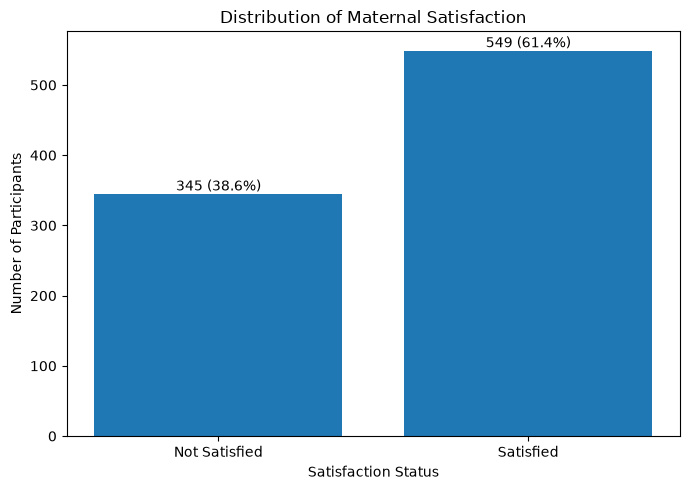

In [35]:
import matplotlib.pyplot as plt

# Count the satisfaction categories
satisfaction_counts = data["satisfaction"].value_counts().sort_index()

# Calculate percentages
satisfaction_percent = data["satisfaction"].value_counts(
    normalize=True
).sort_index() * 100

# Labels
labels = ["Not Satisfied", "Satisfied"]

# Create bar chart
plt.figure(figsize=(7, 5))

bars = plt.bar(labels, satisfaction_counts.values)

# Add count and percentage above each bar
for bar, count, percent in zip(
    bars,
    satisfaction_counts.values,
    satisfaction_percent.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count} ({percent:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.title("Distribution of Maternal Satisfaction")
plt.xlabel("Satisfaction Status")
plt.ylabel("Number of Participants")
plt.tight_layout()
plt.show()

In [36]:
data["residence_label"] = data["q108reside"].map({
    1: "Urban",
    2: "Rural"
})

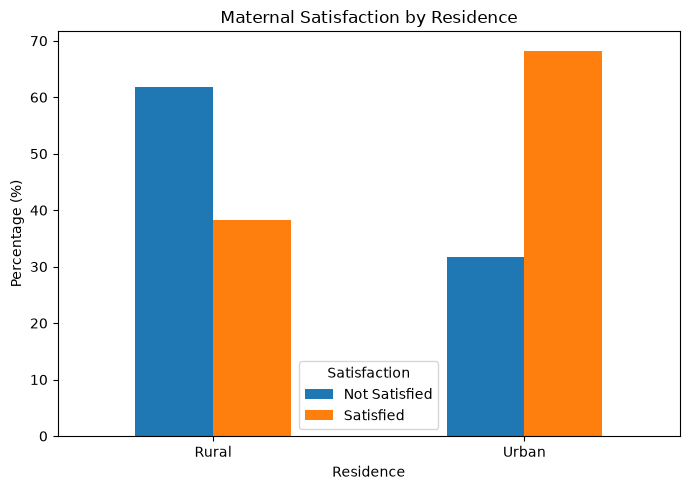

In [37]:
residence_table = pd.crosstab(
    data["residence_label"],
    data["satisfaction"],
    normalize="index"
) * 100

residence_table.columns = ["Not Satisfied", "Satisfied"]

residence_table.plot(kind="bar", figsize=(7, 5))

plt.title("Maternal Satisfaction by Residence")
plt.xlabel("Residence")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Satisfaction")
plt.tight_layout()
plt.show()

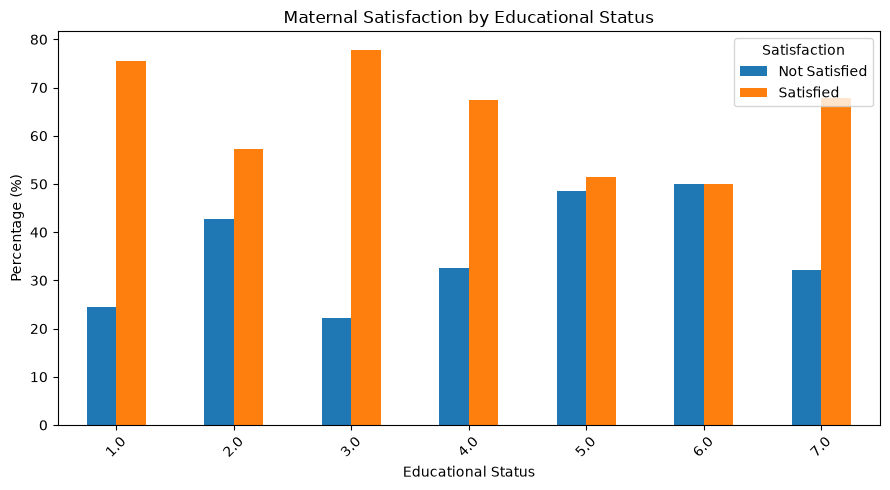

In [38]:
education_table = pd.crosstab(
    data["q105educat"],
    data["satisfaction"],
    normalize="index"
) * 100

education_table.columns = ["Not Satisfied", "Satisfied"]

education_table.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Maternal Satisfaction by Educational Status")
plt.xlabel("Educational Status")
plt.ylabel("Percentage (%)")
plt.legend(title="Satisfaction")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

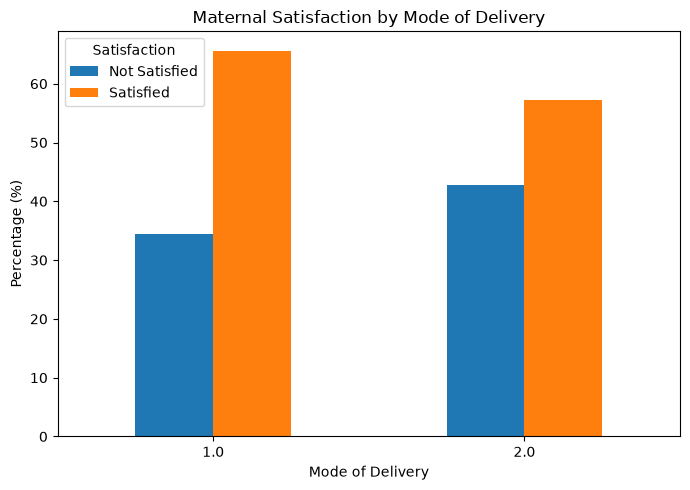

In [39]:
delivery_table = pd.crosstab(
    data["modeofdeliveryrecode"],
    data["satisfaction"],
    normalize="index"
) * 100

delivery_table.columns = ["Not Satisfied", "Satisfied"]

delivery_table.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Maternal Satisfaction by Mode of Delivery")
plt.xlabel("Mode of Delivery")
plt.ylabel("Percentage (%)")
plt.legend(title="Satisfaction")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

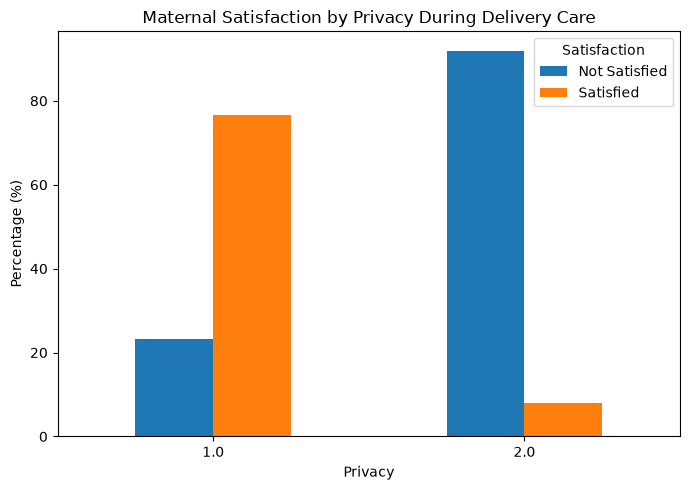

In [40]:
privacy_table = pd.crosstab(
    data["q113privac"],
    data["satisfaction"],
    normalize="index"
) * 100

privacy_table.columns = ["Not Satisfied", "Satisfied"]

privacy_table.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Maternal Satisfaction by Privacy During Delivery Care")
plt.xlabel("Privacy")
plt.ylabel("Percentage (%)")
plt.legend(title="Satisfaction")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [41]:
satisfaction_age = pd.crosstab(
    data["age_group"],
    data["satisfaction"],
    normalize="index"
) * 100

satisfaction_age.columns = ["Not Satisfied", "Satisfied"]

satisfaction_age.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Maternal Satisfaction by Age Group")
plt.xlabel("Maternal Age Group")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Satisfaction")
plt.tight_layout()
plt.show()

KeyError: 'age_group'

#### make tables using spss labels

In [ ]:
def labeled_frequency_table(data, variable, meta):
    frequency = data[variable].value_counts(dropna=False)

    percentage = (
        data[variable]
        .value_counts(normalize=True, dropna=False) * 100
    )

    labels = meta.variable_value_labels.get(variable, {})

    table = pd.DataFrame({
        "Frequency": frequency,
        "Percentage": percentage.round(2)
    })

    table.index = [
        labels.get(value, "Missing" if pd.isna(value) else str(value))
        for value in table.index
    ]

    return table

In [ ]:
labeled_frequency_table(data, "q108reside", meta)

,Frequency,Percentage
urban,690,77.18
rural,204,22.82


In [ ]:
labeled_frequency_table(data, "q102mstatu", meta)

,Frequency,Percentage
married,712,79.64
single,98,10.96
cohabited,67,7.49
widowed,10,1.12
divorced,7,0.78


In [ ]:
labeled_frequency_table(data, "q105educat", meta)

,Frequency,Percentage
diploma and above,321,35.91
grade 11 to 12,154,17.23
grade 9 to 10,146,16.33
unable to read and write,117,13.09
grade 5 to 8,80,8.95
able to read and write,49,5.48
grade 1 to 4,27,3.02


In [ ]:
labeled_frequency_table(data, "q206delimo", meta)

,Frequency,Percentage
CS,446,49.89
spontaneous vaginal delivery,310,34.68
assisted delivery,138,15.44


In [ ]:
labeled_frequency_table(data, "satisfaction", meta)

,Frequency,Percentage
satisfied,549,61.41
not satisfied,345,38.59


In [ ]:
categorical_variables = ["q102mstatu","q103religi","q104ethini","q105educat","q106occupa","q108reside",
    "q110reason","q111timeta","q112waitpl","q113privac","q201parity","q202cpplan","q203ancatt","q204hivres",
    "q206delimo","q207nstatu","q208pdhsta","q209nsex","q301greeti","q302respec","q303delive","q411owners",
    "ageafterrecod","monthlyincomerecode","gestationaagerecode","birthweightofbaby","satisfaction","modeofdeliveryrecode",
    "waitingtimerecode","privacyrecode","encourageandsupportatdeliveryrecode","politenessrecode","availabilityofmedicalequipmentsrecode",
    "counselingrecode","overallcleanessrecode","accessandcleanessoftoiletrecode","waitingareacleanessandconfort","availabilityofbedintheward",
    "distancerecode1","wolkingdistancerecodeinhrs"
]

In [ ]:
for variable in categorical_variables:
    print("\n" + "=" * 60)
    print(variable)
    print("=" * 60)

    print(labeled_frequency_table(data, variable, meta))


q102mstatu
           Frequency  Percentage
married          712       79.64
single            98       10.96
cohabited         67        7.49
widowed           10        1.12
divorced           7        0.78

q103religi
            Frequency  Percentage
orthodox          608       68.01
muslim            193       21.59
protestant         88        9.84
88.0                5        0.56

q104ethini
        Frequency  Percentage
amhara        715       79.98
oromo          95       10.63
agew           47        5.26
tigrie         37        4.14

q105educat
                          Frequency  Percentage
diploma and above               321       35.91
grade 11 to 12                  154       17.23
grade 9 to 10                   146       16.33
unable to read and write        117       13.09
grade 5 to 8                     80        8.95
able to read and write           49        5.48
grade 1 to 4                     27        3.02

q106occupa
              Frequency  Percentage
hu

## 5.Data management

In [ ]:
print("Number of duplicate rows:", data.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
missing = data.isnull().sum()

missing_table = pd.DataFrame({
    "Missing": missing,
    "Percentage": (missing / len(data) * 100).round(2)
})

missing_table = missing_table[
    missing_table["Missing"] > 0
].sort_values("Percentage", ascending=False)

print(missing_table)

                            Missing  Percentage
wolkingdistancerecodeinhrs      619       69.24
q1092disth                      574       64.21


In [ ]:
for col in data.columns:
    n_unique = data[col].nunique(dropna=True)

    if n_unique <= 1:
        print(
            f"{col}: {n_unique} unique non-missing value(s)"
        )

wolkingdistancerecodeinhrs: 1 unique non-missing value(s)


In [ ]:
for col in numerical_variables:
    print("\n", col)
    print("Lowest values:")
    print(data[col].nsmallest(5).tolist())
    print("Highest values:")
    print(data[col].nlargest(5).tolist())


 q101age
Lowest values:
[17.0, 17.0, 18.0, 18.0, 18.0]
Highest values:
[42.0, 39.0, 39.0, 39.0, 39.0]

 q107mincom
Lowest values:
[200.0, 200.0, 260.0, 285.0, 285.0]
Highest values:
[50000.0, 45001.0, 40001.0, 36001.0, 35002.0]

 q1091distk
Lowest values:
[0.0, 0.0, 0.0, 0.0, 0.0]
Highest values:
[500.0, 400.0, 300.0, 300.0, 250.0]

 q1092disth
Lowest values:
[1.0, 1.0, 1.0, 1.0, 1.0]
Highest values:
[200.0, 100.0, 60.0, 50.0, 45.0]

 q205ga
Lowest values:
[32.0, 35.0, 36.0, 36.0, 36.0]
Highest values:
[43.0, 43.0, 43.0, 43.0, 43.0]

 q2010bw
Lowest values:
[1111.0, 1500.0, 1500.0, 1500.0, 1800.0]
Highest values:
[5001.0, 5000.0, 5000.0, 4700.0, 4300.0]


In [ ]:
print(data[["q1091distk", "q1092disth"]].describe())

print(data[["q1091distk", "q1092disth"]].corr())

       q1091distk  q1092disth
count  894.000000  320.000000
mean    19.286353   16.671875
std     44.228470   16.815293
min      0.000000    1.000000
25%      0.000000    4.000000
50%      5.000000   12.000000
75%     15.000000   30.000000
max    500.000000  200.000000
            q1091distk  q1092disth
q1091distk    1.000000   -0.061047
q1092disth   -0.061047    1.000000


In [ ]:
print(pd.crosstab(
    data["q206delimo"],
    data["modeofdeliveryrecode"],
    dropna=False
))

modeofdeliveryrecode  1.0  2.0
q206delimo                    
1.0                   310    0
2.0                   138    0
3.0                     0  446


In [ ]:
print(pd.crosstab(
    pd.cut(
        data["q101age"],
        bins=[0, 19, 30, 49],
        labels=["<=19", "20-30", "31-49"]
    ),
    data["ageafterrecod"],
    dropna=False
))

ageafterrecod  1.0  2.0  3.0
q101age                     
<=19            61    0    0
20-30            0  673    0
31-49            0    0  160


#### Satisfaction related variable

In [ ]:
# possible satisfaction-related variables based on the context provided
satisfaction_related = [
    "waitingtimerecode",
    "privacyrecode",
    "encourageandsupportatdeliveryrecode",
    "politenessrecode",
    "availabilityofmedicalequipmentsrecode",
    "counselingrecode",
    "overallcleanessrecode",
    "accessandcleanessoftoiletrecode",
    "waitingareacleanessandconfort",
    "availabilityofbedintheward"
]

for col in satisfaction_related:
    print("\n", col)
    print(data[col].value_counts(dropna=False).sort_index())


 waitingtimerecode
waitingtimerecode
1.0    202
2.0    692
Name: count, dtype: int64

 privacyrecode
privacyrecode
1.0    187
2.0    707
Name: count, dtype: int64

 encourageandsupportatdeliveryrecode
encourageandsupportatdeliveryrecode
1.0    175
2.0    719
Name: count, dtype: int64

 politenessrecode
politenessrecode
1.0    183
2.0    711
Name: count, dtype: int64

 availabilityofmedicalequipmentsrecode
availabilityofmedicalequipmentsrecode
1.0    198
2.0    696
Name: count, dtype: int64

 counselingrecode
counselingrecode
1.0    218
2.0    676
Name: count, dtype: int64

 overallcleanessrecode
overallcleanessrecode
1.0    303
2.0    591
Name: count, dtype: int64

 accessandcleanessoftoiletrecode
accessandcleanessoftoiletrecode
1.0    388
2.0    506
Name: count, dtype: int64

 waitingareacleanessandconfort
waitingareacleanessandconfort
1.0    333
2.0    561
Name: count, dtype: int64

 availabilityofbedintheward
availabilityofbedintheward
1.0    349
2.0    545
Name: count, dtype: int6

In [ ]:
for col in satisfaction_related:
    print("\n==============================")
    print(col)
    print(pd.crosstab(
        data[col],
        data["satisfaction"],
        normalize="index"
    ).round(3))


waitingtimerecode
satisfaction         1.0    2.0
waitingtimerecode              
1.0                0.936  0.064
2.0                0.225  0.775

privacyrecode
satisfaction     1.0    2.0
privacyrecode              
1.0            0.979  0.021
2.0            0.229  0.771

encourageandsupportatdeliveryrecode
satisfaction                           1.0    2.0
encourageandsupportatdeliveryrecode              
1.0                                  0.971  0.029
2.0                                  0.243  0.757

politenessrecode
satisfaction        1.0    2.0
politenessrecode              
1.0               0.978  0.022
2.0               0.233  0.767

availabilityofmedicalequipmentsrecode
satisfaction                             1.0    2.0
availabilityofmedicalequipmentsrecode              
1.0                                    0.904  0.096
2.0                                    0.239  0.761

counselingrecode
satisfaction        1.0    2.0
counselingrecode              
1.0               0.

In [ ]:
for col in ["q104ethini", "q106occupa"]:
    print("\n", col)
    print(data[col].value_counts(dropna=False).sort_index())


 q104ethini
q104ethini
1.0    715
2.0     95
3.0     37
4.0     47
Name: count, dtype: int64

 q106occupa
q106occupa
1.0     263
2.0     128
3.0     288
4.0      74
5.0      39
88.0    102
Name: count, dtype: int64


In [ ]:
missing_summary = data.isnull().sum().sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing": missing_summary,
    "Percentage": (missing_summary / len(data) * 100).round(2)
})

print(missing_summary[missing_summary["Missing"] > 0])

                            Missing  Percentage
wolkingdistancerecodeinhrs      619       69.24
q1092disth                      574       64.21


In [ ]:
candidate_features = [
    "q101age",
    "q102mstatu",
    "q103religi",
    "q104ethini",
    "q105educat",
    "q106occupa",
    "q107mincom",
    "q108reside",
    "q1091distk",
    "q110reason",
    "q111timeta",
    "q112waitpl",
    "q113privac",
    "q201parity",
    "q202cpplan",
    "q203ancatt",
    "q204hivres",
    "q205ga",
    "q207nstatu",
    "q208pdhsta",
    "q209nsex",
    "q2010bw",
    "q301greeti",
    "q302respec",
    "q303delive",
    "q411owners",
    "modeofdeliveryrecode"
]

print("Number of candidate features:", len(candidate_features))

Number of candidate features: 27


In [ ]:
missing_candidates = data[candidate_features].isnull().sum()

missing_candidates = pd.DataFrame({
    "Missing": missing_candidates,
    "Percentage": (missing_candidates / len(data) * 100).round(2)
})

print(missing_candidates[missing_candidates["Missing"] > 0])

Empty DataFrame
Columns: [Missing, Percentage]
Index: []


In [ ]:
print("Candidate features and data types:")
print(data[candidate_features].dtypes)

Candidate features and data types:
q101age                 float64
q102mstatu              float64
q103religi              float64
q104ethini              float64
q105educat              float64
q106occupa              float64
q107mincom              float64
q108reside              float64
q1091distk              float64
q110reason              float64
q111timeta              float64
q112waitpl              float64
q113privac              float64
q201parity              float64
q202cpplan              float64
q203ancatt              float64
q204hivres              float64
q205ga                  float64
q207nstatu              float64
q208pdhsta              float64
q209nsex                float64
q2010bw                 float64
q301greeti              float64
q302respec              float64
q303delive              float64
q411owners              float64
modeofdeliveryrecode    float64
dtype: object


In [ ]:
numerical_features = [
    "q101age",
    "q107mincom",
    "q1091distk",
    "q205ga",
    "q2010bw"
]

categorical_features = [
    "q102mstatu",
    "q103religi",
    "q104ethini",
    "q105educat",
    "q106occupa",
    "q108reside",
    "q110reason",
    "q111timeta",
    "q112waitpl",
    "q113privac",
    "q201parity",
    "q202cpplan",
    "q203ancatt",
    "q204hivres",
    "q207nstatu",
    "q208pdhsta",
    "q209nsex",
    "q301greeti",
    "q302respec",
    "q303delive",
    "q411owners",
    "modeofdeliveryrecode"
]

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 5
Categorical features: 22


#### preparing target variable

In [ ]:
data["satisfaction_binary"] = data["satisfaction"].map({
    1.0: 0,
    2.0: 1
})

print(data["satisfaction_binary"].value_counts())

satisfaction_binary
1    549
0    345
Name: count, dtype: int64


#### Create x and y

In [ ]:
X = data[candidate_features].copy()
y = data["satisfaction_binary"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (894, 27)
y shape: (894,)


#### Train and Test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (715, 27)
Testing set: (179, 27)


### one hot encoding + scaling

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features)
    ]
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (715, 45)
Processed testing shape: (179, 45)


---

# Final Model: 10 Selected Features

The earlier 27-feature model was removed from this notebook. The cells below contain the final reduced Logistic Regression model used for deployment.


### new Training

In [ ]:
selected_features = [
    "q411owners",
    "q112waitpl",
    "q301greeti",
    "q113privac",
    "q111timeta",
    "q110reason",
    "q108reside",
    "q302respec",
    "q1091distk",
    "q102mstatu"
]

print("Selected features:")
for i, feature in enumerate(selected_features, 1):
    print(i, feature)

Selected features:
1 q411owners
2 q112waitpl
3 q301greeti
4 q113privac
5 q111timeta
6 q110reason
7 q108reside
8 q302respec
9 q1091distk
10 q102mstatu


In [ ]:
X_reduced = data[selected_features].copy()

print("Reduced X shape:", X_reduced.shape)

Reduced X shape: (894, 10)


In [ ]:
from sklearn.model_selection import train_test_split

X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train_red.shape)
print("Testing :", X_test_red.shape)

Training: (715, 10)
Testing : (179, 10)


In [ ]:
numerical_features_red = [
    "q1091distk"
]

categorical_features_red = [
    "q411owners",
    "q112waitpl",
    "q301greeti",
    "q113privac",
    "q111timeta",
    "q110reason",
    "q108reside",
    "q302respec",
    "q102mstatu"
]

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

preprocessor_reduced = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features_red),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ), categorical_features_red)
    ]
)

logistic_model_reduced = Pipeline([
    ("preprocessor", preprocessor_reduced),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])

In [ ]:
logistic_model_reduced.fit(
    X_train_red,
    y_train_red
)

print("Reduced Logistic Regression model trained successfully.")

Reduced Logistic Regression model trained successfully.


In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {"classifier__C": [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0, 10.0]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(logistic_model_reduced, param_grid, scoring="precision", cv=cv, n_jobs=-1)
grid.fit(X_train_red, y_train_red)

print("Best C:", grid.best_params_)
logistic_model_reduced = grid.best_estimator_  # replace with the tuned version

#y_pred_red = logistic_model_reduced.predict(X_test_red)
y_prob_red = logistic_model_reduced.predict_proba(X_test_red)[:, 1]

Best C: {'classifier__C': 2.0}


In [ ]:
threshold = 0.5 # try 0.55–0.75 depending on how much recall you can sacrifice
y_pred_custom = (y_prob_red >= threshold).astype(int)

from sklearn.metrics import precision_score, recall_score
print("Precision:", precision_score(y_test_red, y_pred_custom))
print("Recall:", recall_score(y_test_red, y_pred_custom))

Precision: 0.8818181818181818
Recall: 0.8818181818181818


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    f1_score,
    brier_score_loss
)

y_pred_red = logistic_model_reduced.predict(X_test_red)
y_prob_red = logistic_model_reduced.predict_proba(X_test_red)[:, 1]

accuracy_red = accuracy_score(y_test_red, y_pred_red)
precision_red = precision_score(y_test_red, y_pred_red)
recall_red = recall_score(y_test_red, y_pred_red)
auc_red = roc_auc_score(y_test_red, y_prob_red)
f1_red = f1_score(y_test_red, y_pred_red)
brier_red = brier_score_loss(y_test_red, y_prob_red)

print("Reduced Model Evaluation")
print("------------------------")
print(f"Accuracy : {accuracy_red:.4f}")
print(f"Precision: {precision_red:.4f}")
print(f"Recall   : {recall_red:.4f}")
print(f"AUC      : {auc_red:.4f}")
print(f"F1 Score : {f1_red:.4f}")
print(f"Brier    : {brier_red:.4f}")

Reduced Model Evaluation
------------------------
Accuracy : 0.8547
Precision: 0.8818
Recall   : 0.8818
AUC      : 0.9165
F1 Score : 0.8818
Brier    : 0.1163


In [ ]:

# ---------------------------------------------------------
# 1. Get predicted probabilities
# ---------------------------------------------------------
# Probability of class 1 = Satisfied
y_prob = logistic_model_reduced.predict_proba(X_test)[:, 1]
# ---------------------------------------------------------
# 2. Test thresholds from 0.20 to 0.60
# ---------------------------------------------------------
thresholds = np.arange(0.20, 0.61, 0.05)
results = []

for threshold in thresholds:
    # Convert probabilities into predictions
    # probability >= threshold -> Satisfied (1)
    # probability < threshold  -> Not Satisfied (0)
    y_pred = (y_prob >= threshold).astype(int)
    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    ).ravel()
    # Recall for Not Satisfied (class 0)
    not_satisfied_recall = tn / (tn + fp)
    # Recall for Satisfied (class 1)
    satisfied_recall = tp / (tp + fn)
    # Other metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )
    results.append({
        "Threshold": threshold,
        "Not Satisfied Recall": not_satisfied_recall,
        "Satisfied Recall": satisfied_recall,
        "Accuracy": accuracy,
        "Precision": precision,
        "F1 Score": f1,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })
# ---------------------------------------------------------
# 3. Create results table
# ---------------------------------------------------------
threshold_results = pd.DataFrame(results)
# ---------------------------------------------------------
# 4. Format percentages
# ---------------------------------------------------------
display_table = threshold_results.copy()
percentage_columns = [
    "Not Satisfied Recall",
    "Satisfied Recall",
    "Accuracy",
    "Precision",
    "F1 Score"
]
for col in percentage_columns:
    display_table[col] = (
        display_table[col] * 100
    ).round(2)

display_table["Threshold"] = display_table["Threshold"].round(2)
# ---------------------------------------------------------
# 5. Display the table
# ---------------------------------------------------------

print("Threshold Analysis")
print("=" * 80)

display(display_table)

Threshold Analysis


,Threshold,Not Satisfied Recall,Satisfied Recall,Accuracy,Precision,F1 Score,TN,FP,FN,TP
0,0.20,47.83,99.09,79.33,75.17,85.49,33,36,1,109
1,0.25,49.28,99.09,79.89,75.69,85.83,34,35,1,109
2,0.30,50.72,99.09,80.45,76.22,86.17,35,34,1,109
3,0.35,56.52,96.36,81.01,77.94,86.18,39,30,4,106
4,0.40,65.22,93.64,82.68,81.10,86.92,45,24,7,103
5,0.45,69.57,90.91,82.68,82.64,86.58,48,21,10,100
6,0.50,81.16,88.18,85.47,88.18,88.18,56,13,13,97
7,0.55,82.61,85.45,84.36,88.68,87.04,57,12,16,94
8,0.60,84.06,81.82,82.68,89.11,85.31,58,11,20,90


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
threshold = 0.50 # try 0.55–0.75 depending on how much recall you can sacrifice
y_pred_custom = (y_prob_red >= threshold).astype(int)
cm = confusion_matrix(y_test_red, y_pred_custom)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test_red,
        y_pred_custom,
        target_names=["Not Satisfied", "Satisfied"]
    )
)

Confusion Matrix:
[[56 13]
 [13 97]]

Classification Report:
               precision    recall  f1-score   support

Not Satisfied       0.81      0.81      0.81        69
    Satisfied       0.88      0.88      0.88       110

     accuracy                           0.85       179
    macro avg       0.85      0.85      0.85       179
 weighted avg       0.85      0.85      0.85       179



In [ ]:
from sklearn.metrics import confusion_matrix

cm_red = confusion_matrix(y_test_red, y_pred_red)

print("Confusion Matrix:")
print(cm_red)

Confusion Matrix:
[[56 13]
 [13 97]]


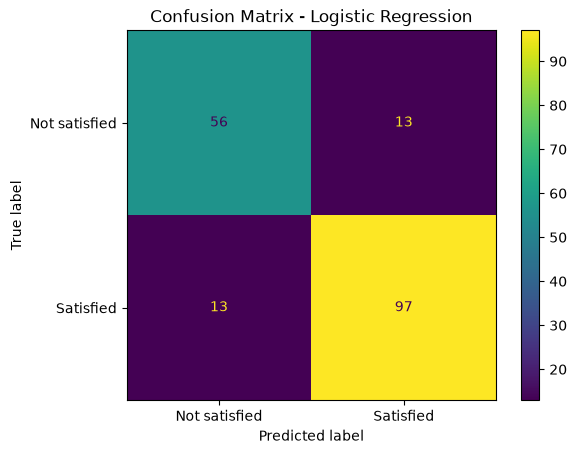

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm_red,
    display_labels=["Not satisfied", "Satisfied"]
).plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd

perm_importance_red = permutation_importance(
    logistic_model_reduced,
    X_test_red,
    y_test_red,
    scoring="roc_auc",
    n_repeats=30,
    random_state=42
)

importance_red = pd.DataFrame({
    "Feature": X_test_red.columns,
    "Importance_Mean": perm_importance_red.importances_mean,
    "Importance_SD": perm_importance_red.importances_std
})

importance_red = importance_red.sort_values(
    by="Importance_Mean",
    ascending=False
)

print(importance_red)

      Feature  Importance_Mean  Importance_SD
1  q112waitpl         0.060277       0.013131
3  q113privac         0.046489       0.012696
2  q301greeti         0.038465       0.011172
0  q411owners         0.034218       0.014296
8  q1091distk         0.020077       0.010084
4  q111timeta         0.010059       0.007501
5  q110reason         0.009840       0.006734
7  q302respec         0.009163       0.005322
9  q102mstatu         0.004370       0.006063
6  q108reside         0.002238       0.002492


In [ ]:
import joblib

joblib.dump(
    logistic_model_reduced,
    "Maternal_Satisfaction_Logistic_Model_10Features.pkl"
)

print("Reduced model saved successfully.")

Reduced model saved successfully.


In [ ]:
import os

print(
    "Model exists:",
    os.path.exists("Maternal_Satisfaction_Logistic_Model_10Features.pkl")
)

Model exists: True
